# 05 — Threshold Selection & Business Impact

Picking a threshold is a business decision, not a modelling one.
A missed failure (false negative) costs far more than a false alarm (false positive)
in industrial maintenance — so we can't just use 0.5.

Cost assumptions (illustrative, should be verified with ops team):
- Missed failure → unplanned downtime + equipment damage: **$50,000**
- False alarm → unnecessary maintenance visit: **$5,000**


In [1]:
import sys, os
sys.path.insert(0, '..')
import pandas as pd, numpy as np, json, joblib
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.dpi'] = 110

from sklearn.model_selection import GroupShuffleSplit
from src.models.xgboost_model   import XGBClassifier
from src.models.evaluate         import cost_based_threshold, business_impact_summary
from src.features.build_features import get_feature_cols

In [2]:
train_feat = pd.read_csv('../data/processed/train_features.csv')
feat_cols  = get_feature_cols(train_feat)

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
_, val_idx = next(gss.split(train_feat, groups=train_feat['unit_id']))
val = train_feat.iloc[val_idx]

xgb_clf = XGBClassifier.load('../models/artifacts/xgb_clf.pkl')
probas   = xgb_clf.predict_proba(val[feat_cols])

## Cost-based threshold sweep

In [3]:
best_t, sweep_df = cost_based_threshold(
    val['will_fail'].values, probas,
    cost_fn=50_000,
    cost_fp=5_000
)

# save best threshold for API
os.makedirs('../models/artifacts', exist_ok=True)
with open('../models/artifacts/best_threshold.json', 'w') as f:
    json.dump({'threshold': best_t, 'cost_fn': 50000, 'cost_fp': 5000}, f)
print(f"\nBest threshold saved: {best_t}")


── Cost-Based Threshold Selection ──
  FN cost (missed failure) : $50,000
  FP cost (false alarm)    : $5,000
  Best threshold           : 0.01
  Min expected cost / batch: $7,820,000

Best threshold saved: 0.01


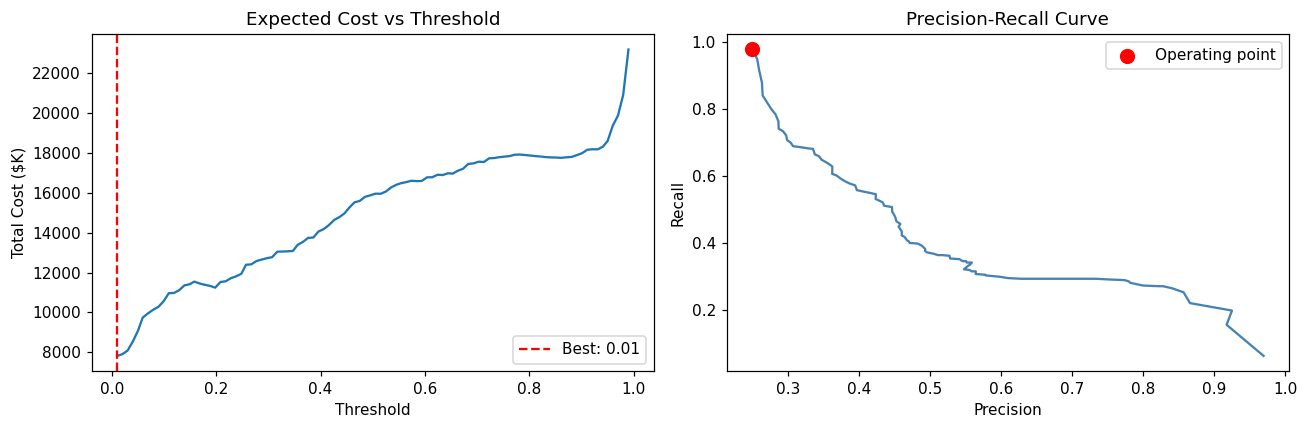

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))

axes[0].plot(sweep_df['threshold'], sweep_df['total_cost'] / 1000)
axes[0].axvline(best_t, color='red', linestyle='--', label=f'Best: {best_t}')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Total Cost ($K)')
axes[0].set_title('Expected Cost vs Threshold')
axes[0].legend()

axes[1].plot(sweep_df['precision'], sweep_df['recall'], color='steelblue')
best_row = sweep_df.iloc[(sweep_df['threshold'] - best_t).abs().argsort()[:1]]
axes[1].scatter(best_row['precision'], best_row['recall'],
                color='red', zorder=5, s=80, label='Operating point')
axes[1].set_xlabel('Precision')
axes[1].set_ylabel('Recall')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend()

plt.tight_layout()
plt.show()

## Annual business impact estimate

In [5]:
# use metrics at chosen threshold
from src.models.evaluate import evaluate_classifier
metrics = evaluate_classifier(val['will_fail'].values, probas,
                              threshold=best_t, label='XGBoost @ cost-optimal threshold')

impact = business_impact_summary(
    n_units_fleet=500,
    recall=metrics['recall'],
    precision=metrics['precision'],
    failure_rate_per_year=0.15,
    cost_per_failure=50_000,
    cost_per_false_alarm=5_000
)


── XGBoost @ cost-optimal threshold — Failure Classifier (threshold=0.01) ──
  AUC         : 0.8447
  F1          : 0.3984
  Precision   : 0.2501
  Recall      : 0.9778
  Confusion Matrix:
[[1721 1454]
 [  11  485]]

── Estimated Annual Business Impact ──
  Fleet size              : 500 units
  Expected failures / yr  : 75.0
  Failures caught         : 73.3  (recall=0.98)
  False alarms / yr       : 318.7
  Cost avoided            : $3,666,835
  Wasted maintenance cost : $1,593,476
  NET benefit             : $2,073,359 / year
  (Assumptions: all figures are illustrative estimates)
